In [10]:
import pandas as pd
from pathlib import Path

# Run with cwd = thesis repo root, or from 04_SentimentAnalysis (then we go up one level).
root = Path.cwd()
if root.name == "04_SentimentAnalysis":
    root = root.parent

df_topic_assignments = pd.read_csv(root / "02_TopicModeling/outputs/03_new_topic_assignments.csv")
df = pd.read_csv(root / "04_SentimentAnalysis/outputs/emotion_fulltext_resultsv2.csv")

_manual = ["Manual Topic Label", "Manual Cluster Label"]
df = df.merge(
    df_topic_assignments[["row_id", *_manual]].drop_duplicates("row_id"),
    on="row_id",
    how="left",
)

anger_col = "emotion_anger"
df[anger_col] = pd.to_numeric(df[anger_col], errors="coerce")
fear_col = "emotion_fear"
df[fear_col] = pd.to_numeric(df[fear_col], errors="coerce")


In [11]:
df['Manual Cluster Label'].value_counts()

Manual Cluster Label
German Party Politics                        2267
Russia (-Ukraine) Diplomacy & Sanctions      2038
Miscellaneous                                1748
US & Transatlantic Politics                  1747
Russia-Ukraine War                           1305
Middle East                                  1303
German Economy & Industry                    1293
Social Policy & Welfare                      1260
International Affairs                         995
Energy, Climate & Environment                 950
Justice System & Political Conflict           934
Migration & Internal Security                 775
Free Speech, Crime & Political Repression     762
Media & Information Ecosystem                 639
Finance & Markets                             551
German Military & Defense                     437
Identity & Culture War                        426
Health & COVID-19                             378
Name: count, dtype: int64

### Save df as csv for further use

In [12]:
df.to_csv(root / "04_SentimentAnalysis/outputs/emotion_fulltext_with_topiclabels.csv", index=False)

### Domestic vs. international topic overall

anger

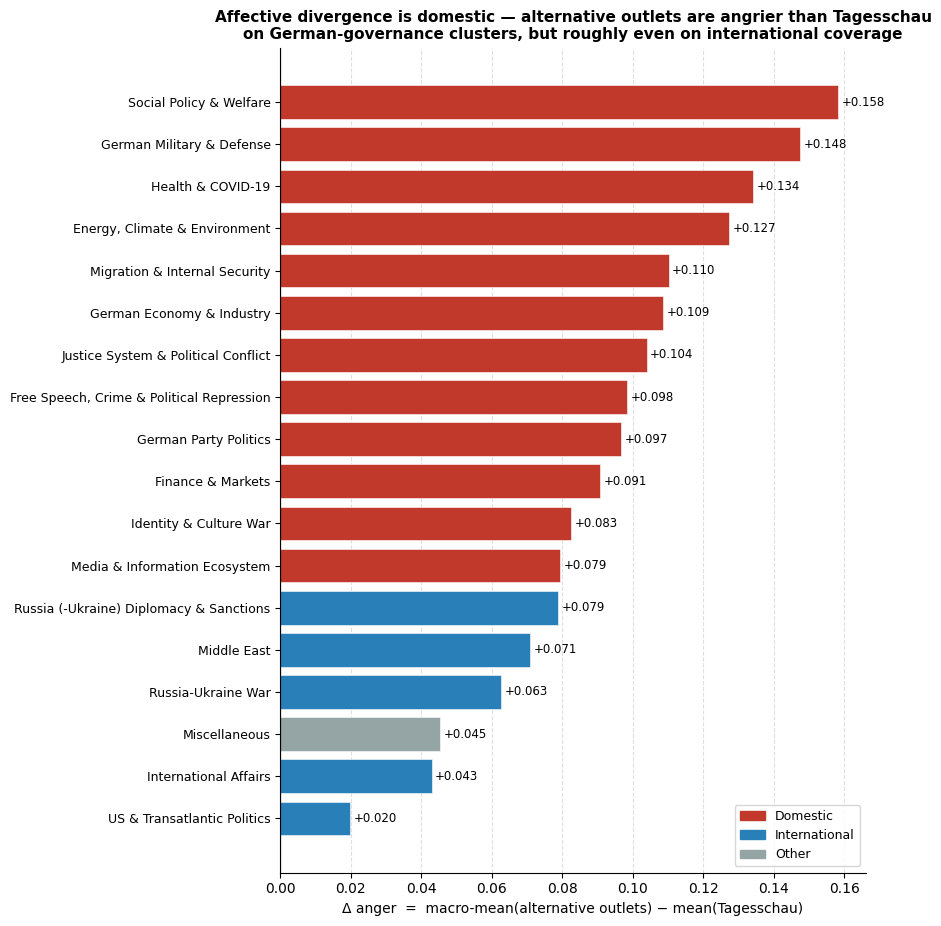

In [13]:
# ── Δ anger per cluster: mean(alternative outlets) − mean(Tagesschau) ────────
# Bars coloured by topic geography: Domestic / International / Other
# Alternative-outlet side uses macro-mean (avg of per-outlet means) to avoid
# size-imbalance bias across outlets.

import numpy as np
from matplotlib.patches import Patch
import pandas as pd
import matplotlib.pyplot as plt

DOMESTIC = {
    "Social Policy & Welfare",
    "Health & COVID-19",
    "Energy, Climate & Environment",
    "German Economy & Industry",
    "Migration & Internal Security",
    "German Party Politics",
    "Free Speech, Crime & Political Repression",
    "Media & Information Ecosystem",
    "Justice System & Political Conflict",
    "Identity & Culture War",
    "Finance & Markets",
    "German Military & Defense",
}
INTERNATIONAL = {
    "Middle East",
    "Russia (-Ukraine) Diplomacy & Sanctions",
    "US & Transatlantic Politics",
    "Russia-Ukraine War",
    "International Affairs",
}

GEO_COLOR = {"Domestic": "#c0392b", "International": "#2980b9", "Other": "#95a5a6"}

def _geo(cluster):
    if cluster in DOMESTIC:      return "Domestic"
    if cluster in INTERNATIONAL: return "International"
    return "Other"

min_n = 10

tg  = df[df["source"] == "Tagesschau"]
alt = df[df["source"] != "Tagesschau"]

# Tagesschau: grand mean per cluster
tg_means = tg.groupby("Manual Cluster Label")[anger_col].mean()

# Alternative outlets: macro-mean (avg of per-outlet means per cluster)
alt_macro = (
    alt.groupby(["Manual Cluster Label", "source"])[anger_col]
    .mean()
    .groupby("Manual Cluster Label")
    .mean()
)

# Keep clusters with enough articles in BOTH groups
tg_n  = tg.groupby("Manual Cluster Label").size()
alt_n = alt.groupby("Manual Cluster Label").size()
keep  = tg_n.index.intersection(alt_n.index).intersection(alt_macro.index)
keep  = keep[(tg_n[keep] >= min_n) & (alt_n[keep] >= min_n)]

delta = (alt_macro[keep] - tg_means[keep]).sort_values(ascending=True)

colors = [GEO_COLOR[_geo(c)] for c in delta.index]

fig, ax = plt.subplots(figsize=(9, max(5, len(delta) * 0.52)))

bars = ax.barh(delta.index, delta.values, color=colors, edgecolor="white", linewidth=0.4)

for bar, val in zip(bars, delta.values):
    sign  = "+" if val >= 0 else ""
    x_pos = val + (0.001 if val >= 0 else -0.001)
    ha    = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{sign}{val:.3f}", va="center", ha=ha, fontsize=8.5)

ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlabel("Δ anger  =  macro-mean(alternative outlets) − mean(Tagesschau)", fontsize=10)
ax.set_title(
    "Affective divergence is domestic — alternative outlets are angrier than Tagesschau\n"
    "on German-governance clusters, but roughly even on international coverage",
    fontsize=11, fontweight="bold",
)
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)

legend_handles = [Patch(color=c, label=l) for l, c in GEO_COLOR.items()]
ax.legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


In [14]:
# ── Summary: Δ anger domestic vs international — alternative outlets vs Tagesschau
# Uses DOMESTIC / INTERNATIONAL sets defined in the cell above.

def _geo(cluster):
    if cluster in DOMESTIC:      return "Domestic"
    if cluster in INTERNATIONAL: return "International"
    return "Other"

df["geo"] = df["Manual Cluster Label"].map(_geo)

tg  = df[df["source"] == "Tagesschau"]
alt = df[df["source"] != "Tagesschau"]

results = {}
for geo in ("Domestic", "International"):
    tg_mean  = tg[tg["geo"]  == geo][anger_col].mean()
    # macro-mean: average of per-outlet means (corrects for outlet size)
    alt_macro = (
        alt[alt["geo"] == geo]
        .groupby("source")[anger_col].mean()
        .mean()
    )
    delta = alt_macro - tg_mean
    results[geo] = {"Tagesschau": tg_mean, "Alt (macro)": alt_macro, "Δ": delta}
    print(f"{geo:15s}  →  Tagesschau: {tg_mean:.4f}  |  Alt outlets: {alt_macro:.4f}  |  Δ = {delta:+.4f}")


Domestic         →  Tagesschau: 0.6652  |  Alt outlets: 0.7881  |  Δ = +0.1229
International    →  Tagesschau: 0.6871  |  Alt outlets: 0.7367  |  Δ = +0.0497


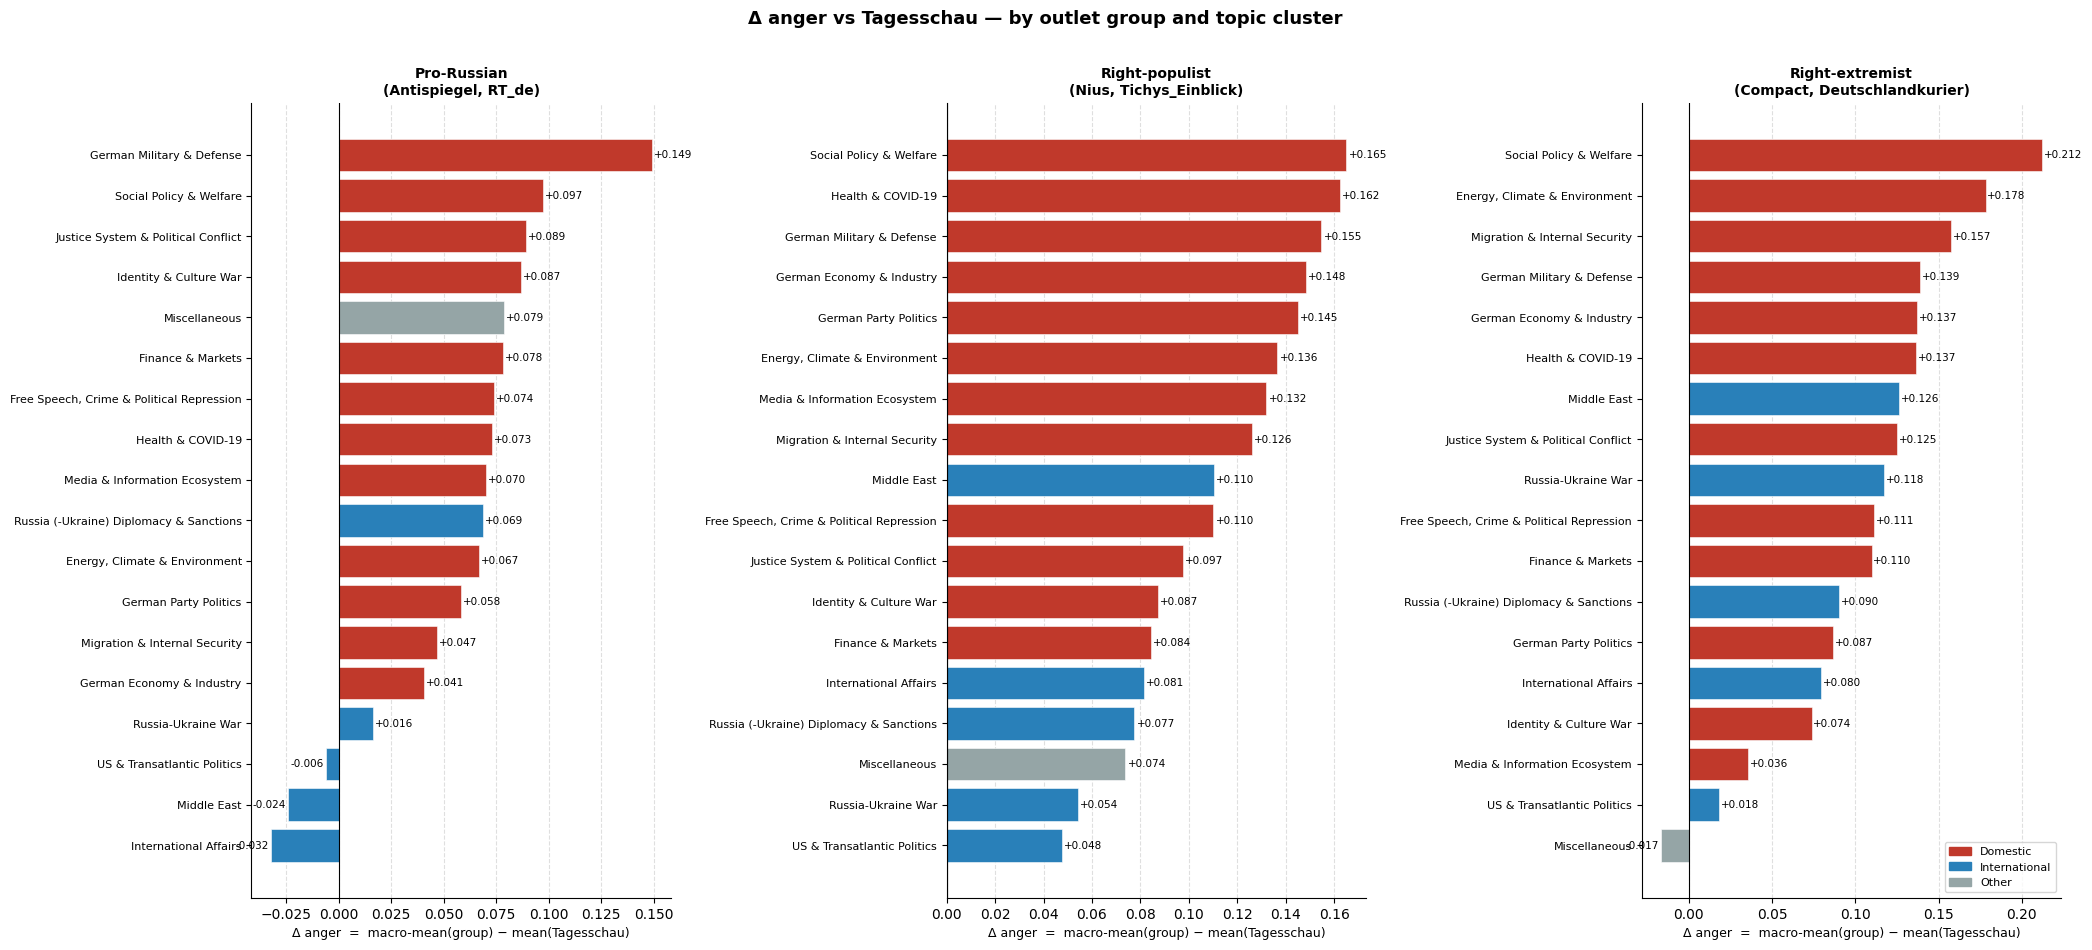

In [15]:
# ── Δ anger per cluster: each outlet group vs Tagesschau ─────────────────────
# One panel per group; same geo-colour coding as the overall chart above.

OUTLET_GROUPS = {
    "Pro-Russian\n(Antispiegel, RT_de)":           ["Antispiegel", "RT_de"],
    "Right-populist\n(Nius, Tichys_Einblick)":     ["Nius", "Tichys_Einblick"],
    "Right-extremist\n(Compact, Deutschlandkurier)": ["Compact", "Deutschlandkurier"],
}

min_n  = 5
tg     = df[df["source"] == "Tagesschau"]
tg_means = tg.groupby("Manual Cluster Label")[anger_col].mean()
tg_n     = tg.groupby("Manual Cluster Label").size()

fig, axes = plt.subplots(1, 3, figsize=(21, max(6, len(tg_means) * 0.52)),
                         sharey=False)

for ax, (group_label, members) in zip(axes, OUTLET_GROUPS.items()):
    grp   = df[df["source"].isin(members)]
    grp_n = grp.groupby("Manual Cluster Label").size()

    # macro-mean across the group's outlets per cluster
    grp_macro = (
        grp.groupby(["Manual Cluster Label", "source"])[anger_col]
        .mean()
        .groupby("Manual Cluster Label")
        .mean()
    )

    keep = (
        tg_n.index
        .intersection(grp_n.index)
        .intersection(grp_macro.index)
    )
    keep = keep[(tg_n[keep] >= min_n) & (grp_n[keep] >= min_n)]

    delta  = (grp_macro[keep] - tg_means[keep]).sort_values(ascending=True)
    colors = [GEO_COLOR[_geo(c)] for c in delta.index]

    bars = ax.barh(delta.index, delta.values, color=colors,
                   edgecolor="white", linewidth=0.4)

    for bar, val in zip(bars, delta.values):
        sign  = "+" if val >= 0 else ""
        x_pos = val + (0.001 if val >= 0 else -0.001)
        ha    = "left" if val >= 0 else "right"
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                f"{sign}{val:.3f}", va="center", ha=ha, fontsize=7.5)

    ax.axvline(0, color="black", linewidth=0.8)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_xlabel("Δ anger  =  macro-mean(group) − mean(Tagesschau)", fontsize=9)
    ax.set_title(group_label, fontsize=10, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# Shared legend on last panel
legend_handles = [Patch(color=c, label=l) for l, c in GEO_COLOR.items()]
axes[-1].legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=8)

fig.suptitle(
    "Δ anger vs Tagesschau — by outlet group and topic cluster",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()


fear

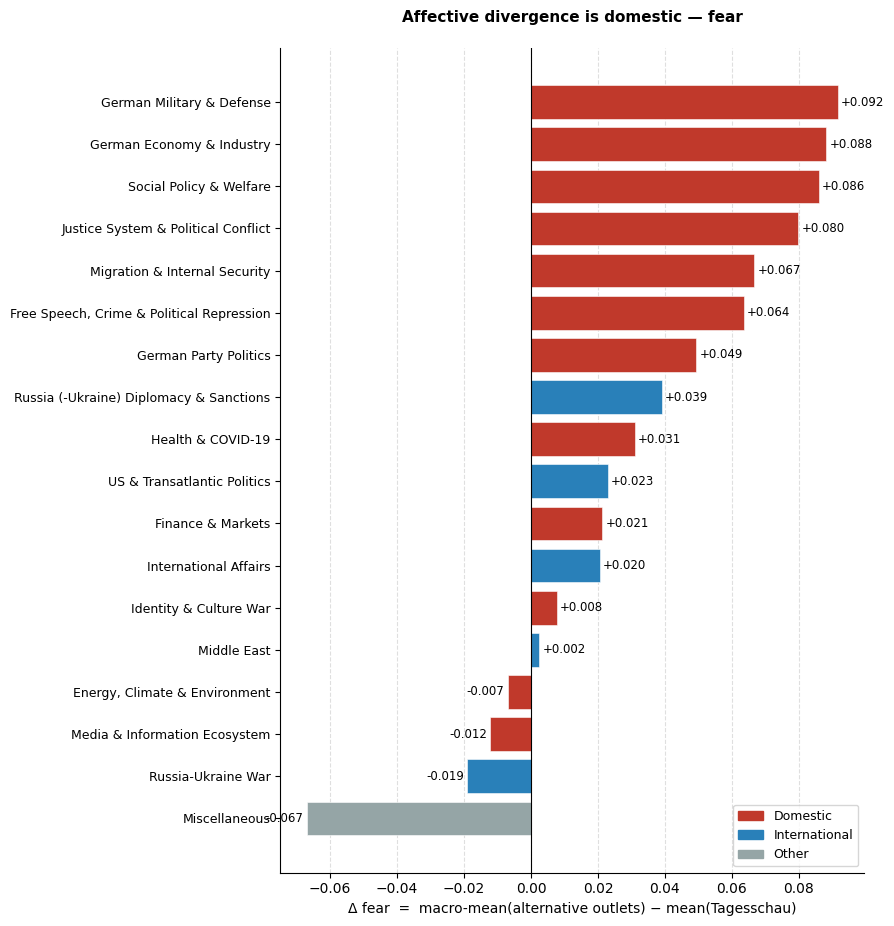

In [16]:
# ── Δ fear per cluster: mean(alternative outlets) − mean(Tagesschau) ────────
# Bars coloured by topic geography: Domestic / International / Other
# Alternative-outlet side uses macro-mean (avg of per-outlet means) to avoid
# size-imbalance bias across outlets.


def _geo(cluster):
    if cluster in DOMESTIC:      return "Domestic"
    if cluster in INTERNATIONAL: return "International"
    return "Other"


min_n = 10

tg  = df[df["source"] == "Tagesschau"]
alt = df[df["source"] != "Tagesschau"]

# Tagesschau: grand mean per cluster
tg_means = tg.groupby("Manual Cluster Label")[fear_col].mean()

# Alternative outlets: macro-mean (avg of per-outlet means per cluster)
alt_macro = (
    alt.groupby(["Manual Cluster Label", "source"])[fear_col]
    .mean()
    .groupby("Manual Cluster Label")
    .mean()
)

# Keep clusters with enough articles in BOTH groups
tg_n  = tg.groupby("Manual Cluster Label").size()
alt_n = alt.groupby("Manual Cluster Label").size()
keep  = tg_n.index.intersection(alt_n.index).intersection(alt_macro.index)
keep  = keep[(tg_n[keep] >= min_n) & (alt_n[keep] >= min_n)]

delta = (alt_macro[keep] - tg_means[keep]).sort_values(ascending=True)

colors = [GEO_COLOR[_geo(c)] for c in delta.index]

fig, ax = plt.subplots(figsize=(9, max(5, len(delta) * 0.52)))

bars = ax.barh(delta.index, delta.values, color=colors, edgecolor="white", linewidth=0.4)

for bar, val in zip(bars, delta.values):
    sign  = "+" if val >= 0 else ""
    x_pos = val + (0.001 if val >= 0 else -0.001)
    ha    = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{sign}{val:.3f}", va="center", ha=ha, fontsize=8.5)

ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlabel("Δ fear  =  macro-mean(alternative outlets) − mean(Tagesschau)", fontsize=10)
ax.set_title(
    "Affective divergence is domestic — fear\n",
    fontsize=11, fontweight="bold",
)
ax.tick_params(axis="y", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)

legend_handles = [Patch(color=c, label=l) for l, c in GEO_COLOR.items()]
ax.legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


In [17]:
# ── Summary: Δ fear domestic vs international — alternative outlets vs Tagesschau
# Uses DOMESTIC / INTERNATIONAL sets defined in the cell above.

def _geo(cluster):
    if cluster in DOMESTIC:      return "Domestic"
    if cluster in INTERNATIONAL: return "International"
    return "Other"

df["geo"] = df["Manual Cluster Label"].map(_geo)

tg  = df[df["source"] == "Tagesschau"]
alt = df[df["source"] != "Tagesschau"]

results = {}
for geo in ("Domestic", "International"):
    tg_mean  = tg[tg["geo"]  == geo][fear_col].mean()
    # macro-mean: average of per-outlet means (corrects for outlet size)
    alt_macro = (
        alt[alt["geo"] == geo]
        .groupby("source")[fear_col].mean()
        .mean()
    )
    delta = alt_macro - tg_mean
    results[geo] = {"Tagesschau": tg_mean, "Alt (macro)": alt_macro, "Δ": delta}
    print(f"{geo:15s}  →  Tagesschau: {tg_mean:.4f}  |  Alt outlets: {alt_macro:.4f}  |  Δ = {delta:+.4f}")


Domestic         →  Tagesschau: 0.2190  |  Alt outlets: 0.2560  |  Δ = +0.0371
International    →  Tagesschau: 0.2697  |  Alt outlets: 0.2711  |  Δ = +0.0013


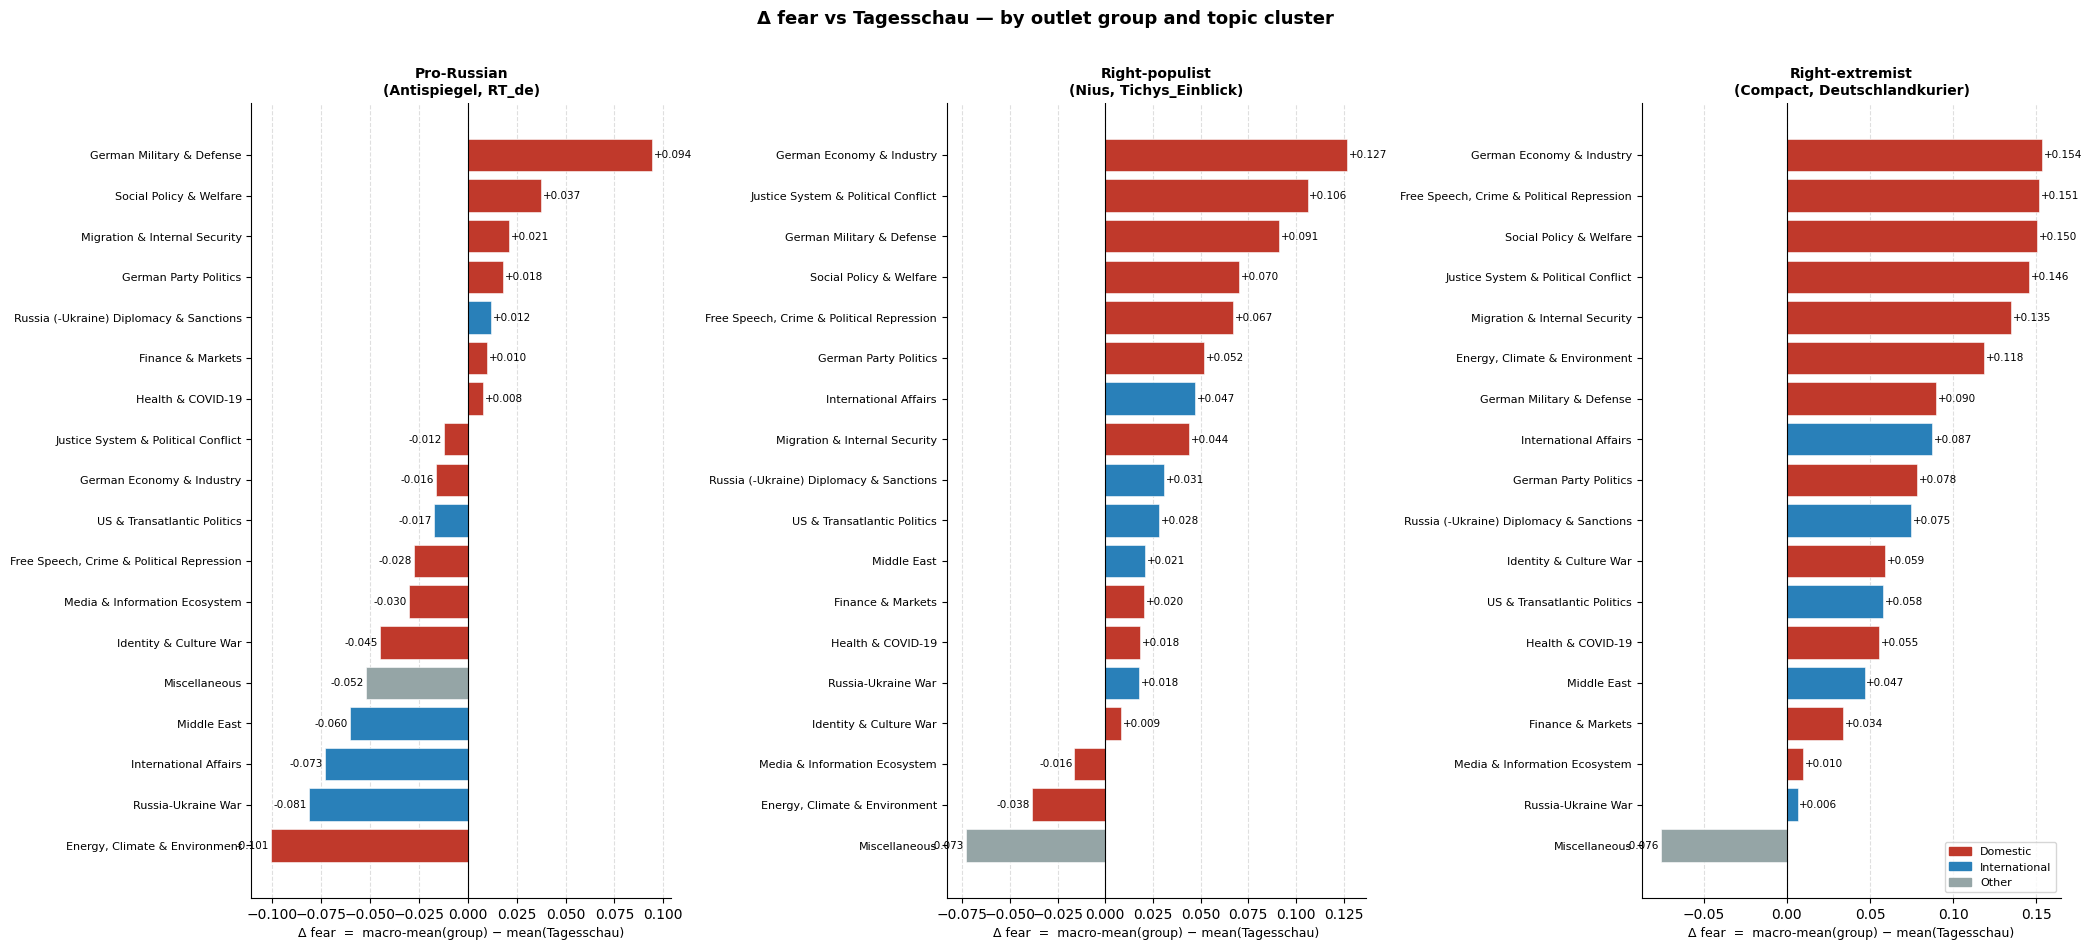

In [18]:
# ── Δ fear per cluster: each outlet group vs Tagesschau ─────────────────────
# One panel per group; same geo-colour coding as the overall chart above.

OUTLET_GROUPS = {
    "Pro-Russian\n(Antispiegel, RT_de)":           ["Antispiegel", "RT_de"],
    "Right-populist\n(Nius, Tichys_Einblick)":     ["Nius", "Tichys_Einblick"],
    "Right-extremist\n(Compact, Deutschlandkurier)": ["Compact", "Deutschlandkurier"],
}

min_n  = 5
tg     = df[df["source"] == "Tagesschau"]
tg_means = tg.groupby("Manual Cluster Label")[fear_col].mean()
tg_n     = tg.groupby("Manual Cluster Label").size()

fig, axes = plt.subplots(1, 3, figsize=(21, max(6, len(tg_means) * 0.52)),
                         sharey=False)

for ax, (group_label, members) in zip(axes, OUTLET_GROUPS.items()):
    grp   = df[df["source"].isin(members)]
    grp_n = grp.groupby("Manual Cluster Label").size()

    # macro-mean across the group's outlets per cluster
    grp_macro = (
        grp.groupby(["Manual Cluster Label", "source"])[fear_col]
        .mean()
        .groupby("Manual Cluster Label")
        .mean()
    )

    keep = (
        tg_n.index
        .intersection(grp_n.index)
        .intersection(grp_macro.index)
    )
    keep = keep[(tg_n[keep] >= min_n) & (grp_n[keep] >= min_n)]

    delta  = (grp_macro[keep] - tg_means[keep]).sort_values(ascending=True)
    colors = [GEO_COLOR[_geo(c)] for c in delta.index]

    bars = ax.barh(delta.index, delta.values, color=colors,
                   edgecolor="white", linewidth=0.4)

    for bar, val in zip(bars, delta.values):
        sign  = "+" if val >= 0 else ""
        x_pos = val + (0.001 if val >= 0 else -0.001)
        ha    = "left" if val >= 0 else "right"
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                f"{sign}{val:.3f}", va="center", ha=ha, fontsize=7.5)

    ax.axvline(0, color="black", linewidth=0.8)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_xlabel("Δ fear  =  macro-mean(group) − mean(Tagesschau)", fontsize=9)
    ax.set_title(group_label, fontsize=10, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# Shared legend on last panel
legend_handles = [Patch(color=c, label=l) for l, c in GEO_COLOR.items()]
axes[-1].legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=8)

fig.suptitle(
    "Δ fear vs Tagesschau — by outlet group and topic cluster",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()


# DELETE below?

### Cluster & outlet level

In [19]:
# Per-topic-cluster × outlet mean anger; colors vs corpus-wide mean anger


if "Manual Cluster Label" not in df.columns or "source" not in df.columns:
    raise ValueError("df must contain 'Manual Cluster Label' and 'source'.")
if not any("anger" in c.lower() for c in df.columns):
    raise ValueError("df must contain an anger score column.")

anger_col = next(c for c in df.columns if "anger" in c.lower())

# Reference: macro-average of per-outlet means (corrects for dataset imbalance)
overall_anger_mean = float(df.groupby("source")[anger_col].mean().mean())

major_topics = df["Manual Cluster Label"].value_counts()
major_topics = major_topics[major_topics > 20].index
df_major = df[df["Manual Cluster Label"].isin(major_topics)].copy()

pivot = (
    df_major.groupby(["Manual Cluster Label", "source"])[anger_col]
    .mean()
    .unstack("source")
)

vals = pivot.to_numpy(dtype=float)
lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
spread = max(hi - overall_anger_mean, overall_anger_mean - lo)
if spread == 0:
    spread = 1e-6
vmin = overall_anger_mean - spread
vmax = overall_anger_mean + spread

pivot = pivot.reindex(index=[x for x in major_topics if x in pivot.index])

plt.figure(figsize=(14, max(6, 0.4 * len(pivot))))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=overall_anger_mean,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    cbar_kws={
        "label": f"Mean {anger_col} (outlet macro-μ = {overall_anger_mean:.3f}; red = above, blue = below)",
    },
)
plt.ylabel("Manual Cluster Label")
plt.xlabel("Source")
plt.title("Mean anger per topic cluster × outlet (diverging scale centered on outlet macro-mean anger)")
plt.tight_layout()
plt.show()



NameError: name 'sns' is not defined

<Figure size 1400x720 with 0 Axes>

### Topic level

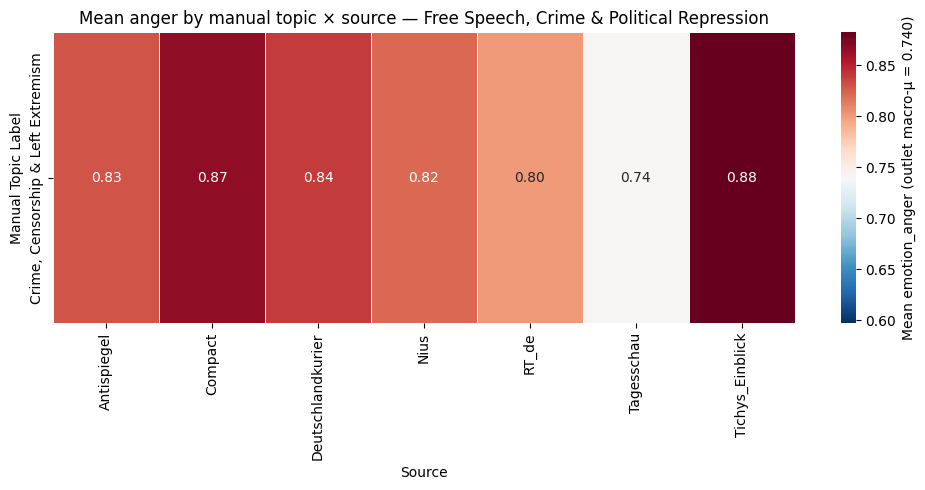

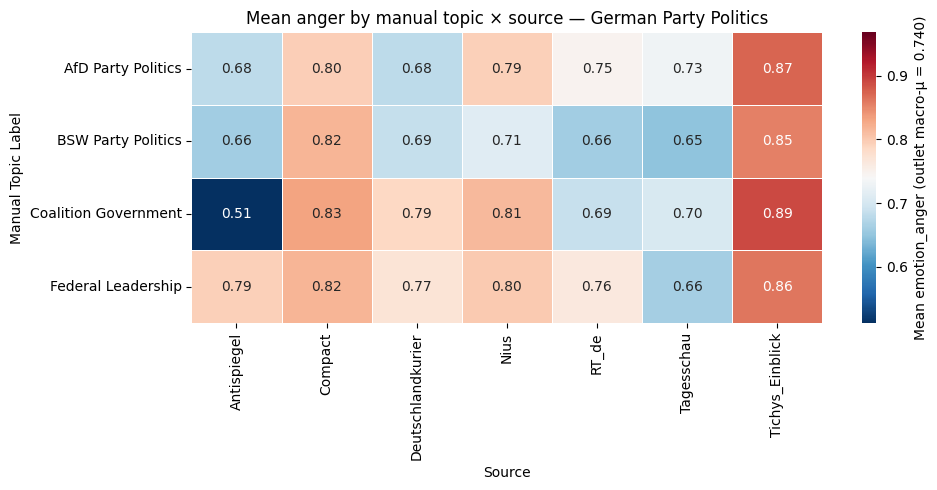

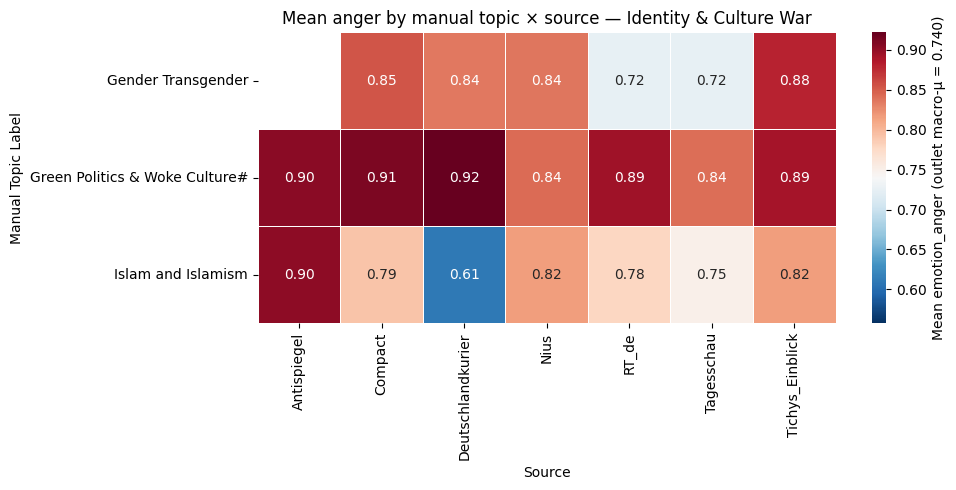

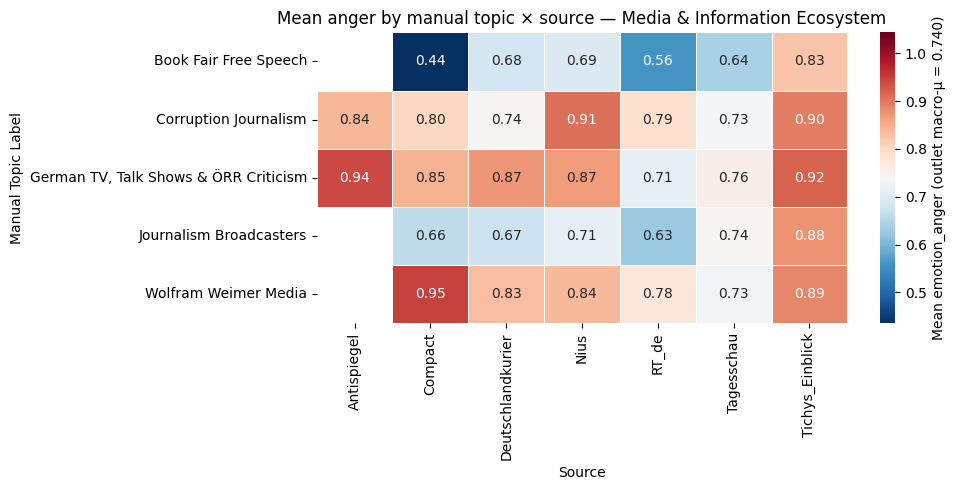

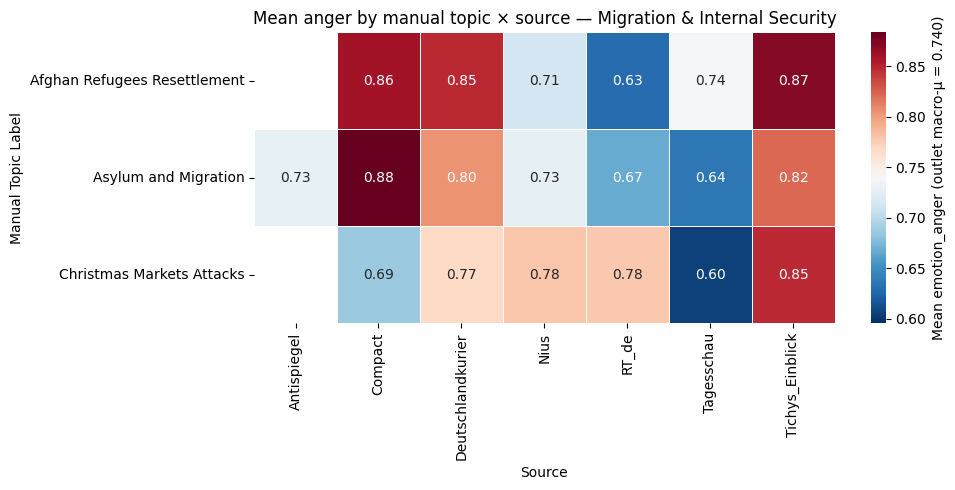

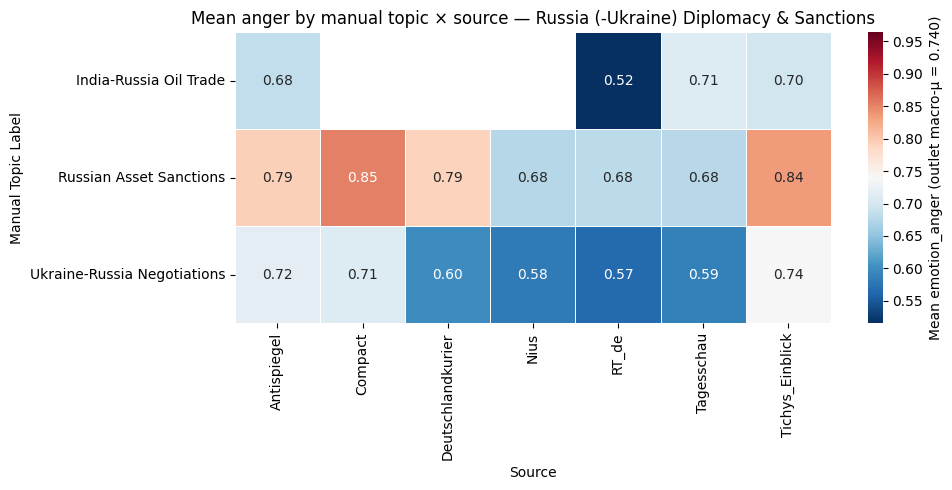

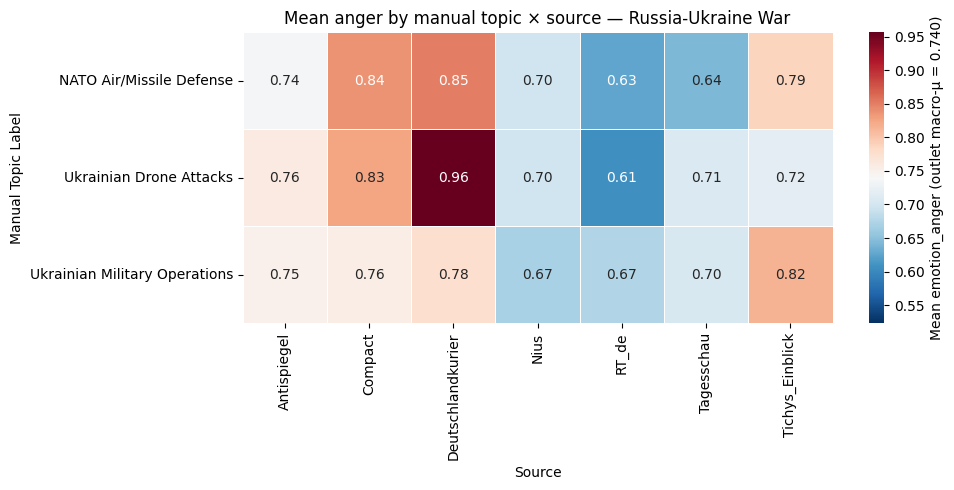

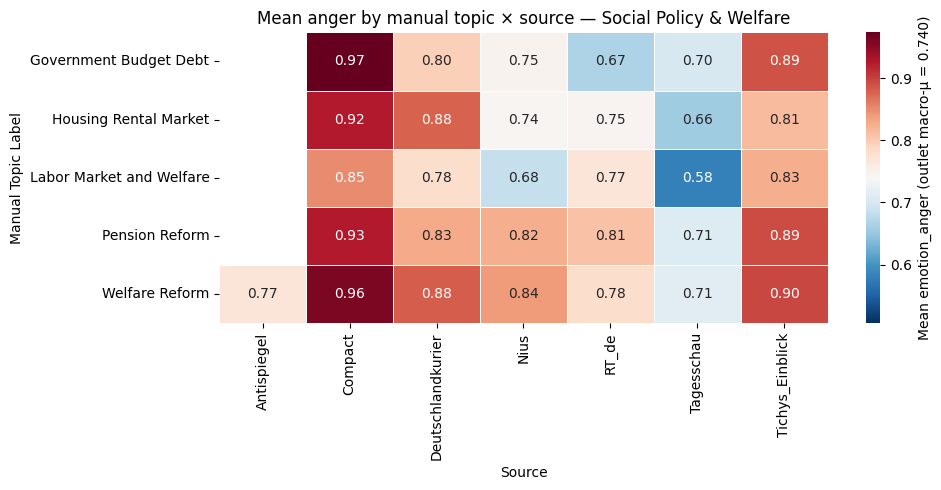

In [ ]:
# One heatmap per selected manual cluster: mean anger by Manual Topic Label × source

CLUSTER_LABELS = [
    "Free Speech, Crime & Political Repression",
    "German Party Politics Total",
    "Identity & Culture War Total",
    "Media & Information Ecosystem Total",
    "Migration & Internal Security",
    "Russia (-Ukraine) Diplomacy & Sanctions",
    "Russia-Ukraine War",
    "Social Policy & Welfare",
]

_ALIASES = {
    "German Party Politics Total": "German Party Politics",
    "Identity & Culture War Total": "Identity & Culture War",
    "Media & Information Ecosystem Total": "Media & Information Ecosystem",
}


def _resolve_manual_cluster(name: str, available: set[str]) -> str | None:
    if name in available:
        return name
    if name in _ALIASES and _ALIASES[name] in available:
        return _ALIASES[name]
    stripped = name[:-6].strip() if name.endswith(" Total") else name.strip()
    if stripped in available:
        return stripped
    return None


if "Manual Topic Label" not in df.columns:
    raise ValueError("df must contain 'Manual Topic Label' (merge topic assignments first).")
if not any("anger" in c.lower() for c in df.columns):
    raise ValueError("No anger column found.")

anger_col = next(c for c in df.columns if "anger" in c.lower())

available = set(df["Manual Cluster Label"].dropna().astype(str).unique())

for raw in CLUSTER_LABELS:
    resolved = _resolve_manual_cluster(raw, available)
    if resolved is None:
        print(f"Skip (unknown label): {raw!r}")
        continue

    sub = df.loc[df["Manual Cluster Label"] == resolved].copy()
    if sub.empty:
        print(f"Skip (no rows): {resolved!r}")
        continue

    # Topic-level: rows = manual topic, columns = outlet
    pivot = (
        sub.groupby(["Manual Topic Label", "source"])[anger_col]
        .mean()
        .unstack("source")
    )

    # Optional: drop manual topics with very few articles in this cluster
    min_n = 5
    topic_n = sub.groupby("Manual Topic Label", dropna=False).size()
    keep = topic_n[topic_n >= min_n].index
    pivot = pivot.reindex(index=pivot.index.intersection(keep)).sort_index()

    if pivot.empty:
        print(f"Skip (no topics with n≥{min_n}): {resolved!r}")
        continue

    vals = pivot.to_numpy(dtype=float)
    lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
    spread = max(hi - overall_anger_mean, overall_anger_mean - lo)
    if spread == 0:
        spread = 1e-6
    vmin, vmax = overall_anger_mean - spread, overall_anger_mean + spread

    n_r, n_c = pivot.shape
    plt.figure(figsize=(max(10, 0.55 * n_c), max(5, 0.38 * n_r)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=overall_anger_mean,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        cbar_kws={"label": f"Mean {anger_col} (outlet macro-μ = {overall_anger_mean:.3f})"},
    )
    plt.title(f"Mean anger by manual topic × source — {resolved}")
    plt.xlabel("Source")
    plt.ylabel("Manual Topic Label")
    plt.tight_layout()
    plt.show()



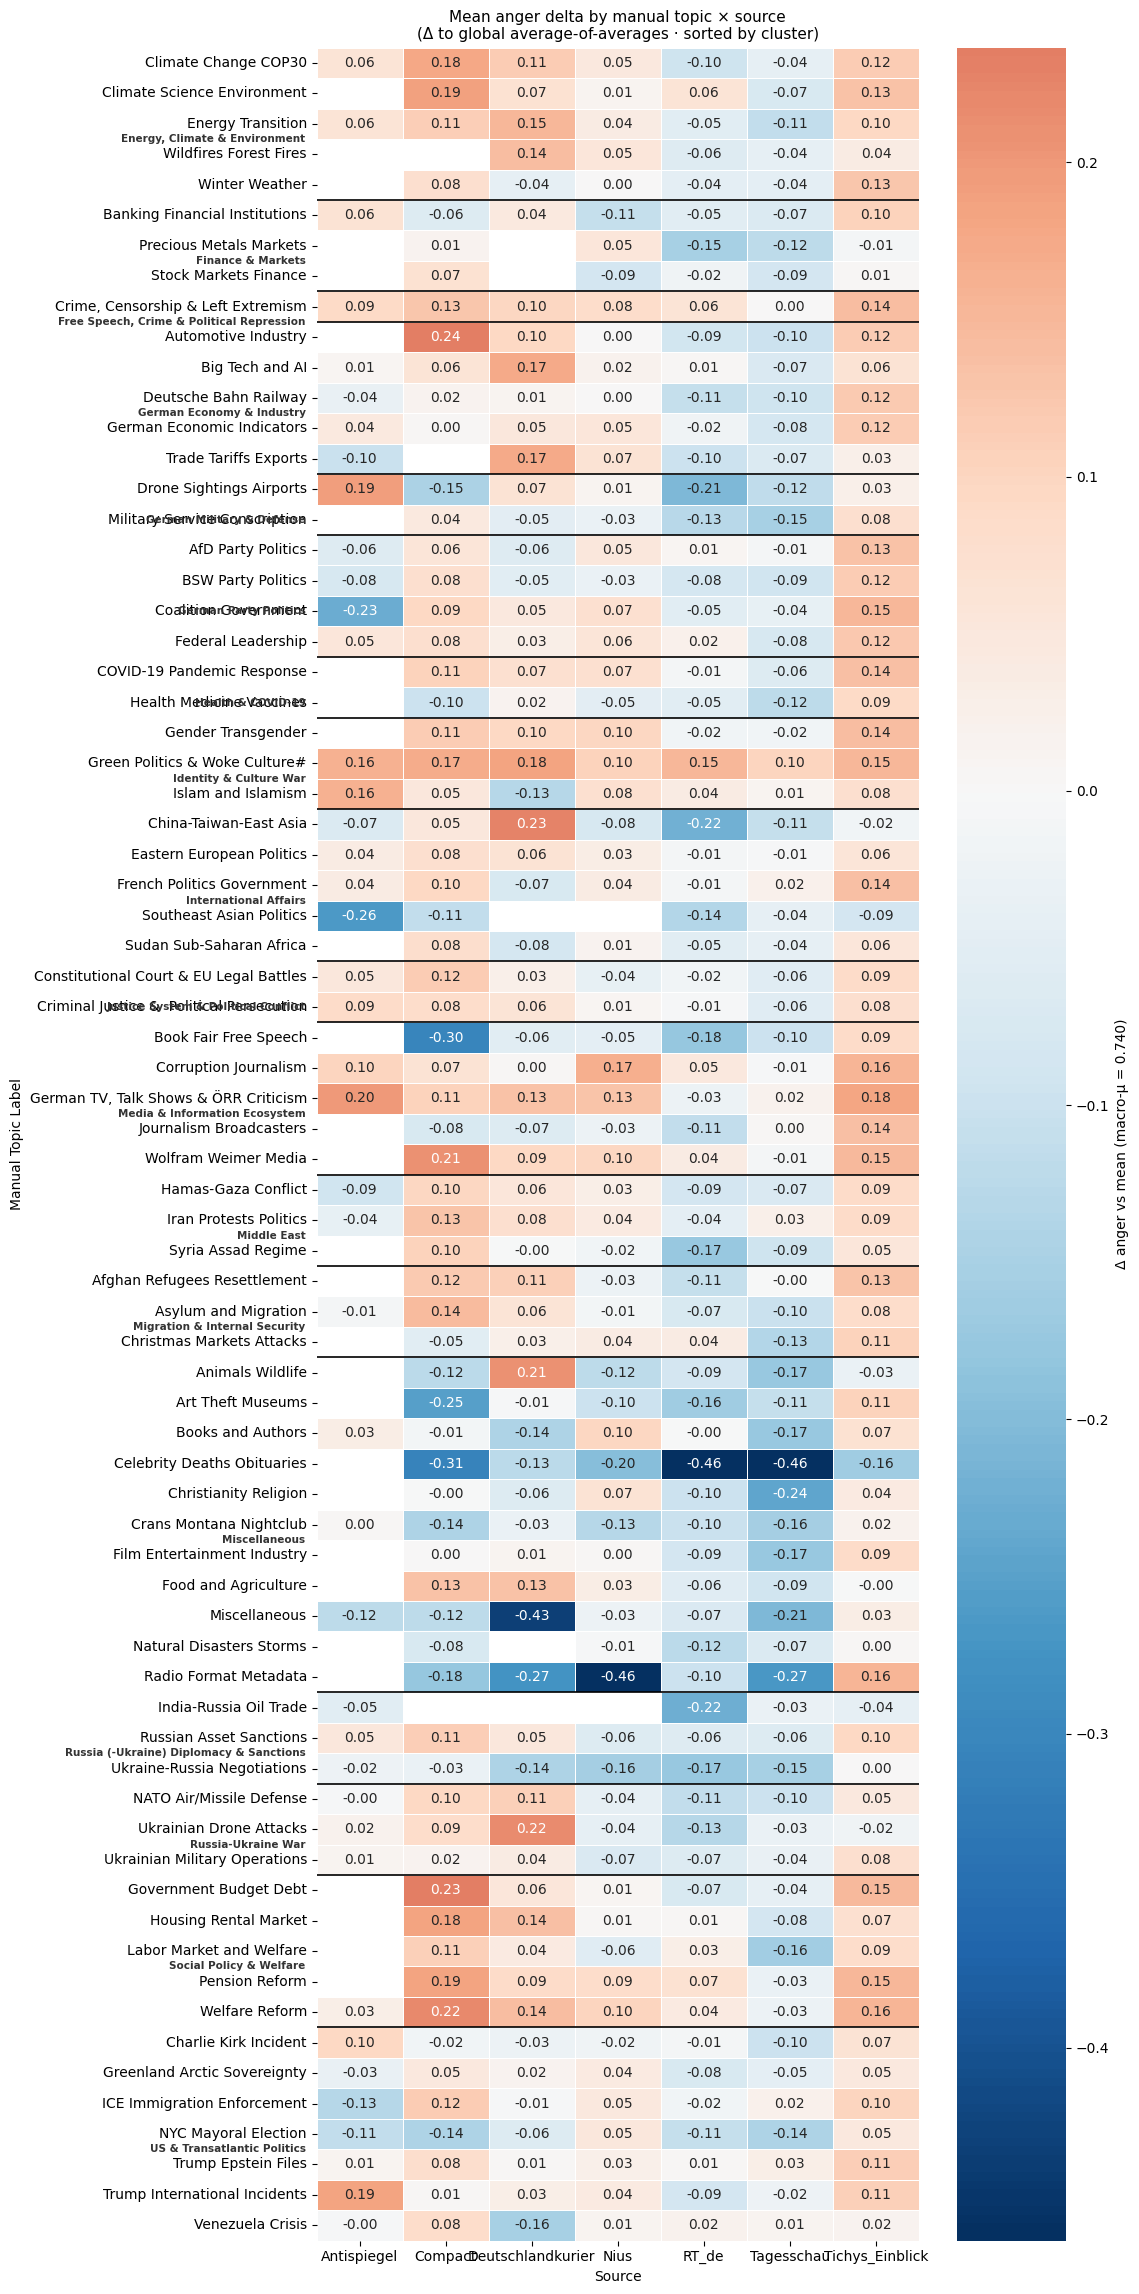

In [ ]:
def _heatmap_clustered(topic_pivot, overall_mean, emotion_name, df):
    """Draw a long heatmap sorted by cluster, with cluster labels on the left."""
    import numpy as np

    # ── min-n filter ──────────────────────────────────────────────────────
    min_n = 5
    topic_counts = df.groupby("Manual Topic Label", dropna=False).size()
    keep_topics  = topic_counts[topic_counts >= min_n].index
    topic_pivot  = topic_pivot.reindex(index=topic_pivot.index.intersection(keep_topics))

    # ── cluster sort order ────────────────────────────────────────────────
    cluster_map = (
        df[["Manual Topic Label", "Manual Cluster Label"]]
        .dropna()
        .drop_duplicates()
        .set_index("Manual Topic Label")["Manual Cluster Label"]
    )
    valid = topic_pivot.index.intersection(cluster_map.index)
    topic_pivot = topic_pivot.loc[valid]
    sort_df = (
        pd.DataFrame({"topic": valid, "cluster": valid.map(cluster_map)})
        .sort_values(["cluster", "topic"])
    )
    topic_pivot = topic_pivot.loc[sort_df["topic"]]
    delta = topic_pivot - overall_mean

    # ── cluster spans for annotations ─────────────────────────────────────
    cl_series = sort_df["cluster"].values
    spans, boundaries = [], []
    prev, start = cl_series[0], 0
    for i, cl in enumerate(cl_series[1:], 1):
        if cl != prev:
            spans.append((prev, start, i))
            boundaries.append(i)
            prev, start = cl, i
    spans.append((prev, start, len(cl_series)))

    # ── figure ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(
        figsize=(max(12, 0.55 * delta.shape[1]),
                 max(7,  0.32 * delta.shape[0]))
    )
    sns.heatmap(
        delta, ax=ax,
        annot=True, fmt=".2f",
        cmap="RdBu_r", center=0,
        linewidths=0.5,
        cbar_kws={"label": f"Δ {emotion_name} vs mean (macro-μ = {overall_mean:.3f})"},
    )

    # ── cluster separator lines ───────────────────────────────────────────
    for b in boundaries:
        ax.axhline(b, color="black", linewidth=1.2)

    # ── cluster labels to the left of the heatmap ─────────────────────────
    for cluster_name, start, end in spans:
        mid = (start + end) / 2 + 0.5
        ax.annotate(
            cluster_name,
            xy=(0, mid),
            xycoords=("axes fraction", "data"),
            xytext=(-8, 0),
            textcoords="offset points",
            ha="right", va="center",
            fontsize=7.5, fontweight="bold",
            annotation_clip=False,
            color="#333333",
        )

    ax.set_title(
        f"Mean {emotion_name} delta by manual topic × source\n"
        f"(Δ to global average-of-averages · sorted by cluster)",
        fontsize=11,
    )
    ax.set_xlabel("Source")
    ax.set_ylabel("Manual Topic Label")
    plt.tight_layout()
    plt.subplots_adjust(left=0.35)   # room for cluster labels
    plt.show()

topic_pivot = (
    df.groupby(["Manual Topic Label", "source"])[anger_col]
    .mean()
    .unstack("source")
)
_heatmap_clustered(topic_pivot, overall_anger_mean, "anger", df)


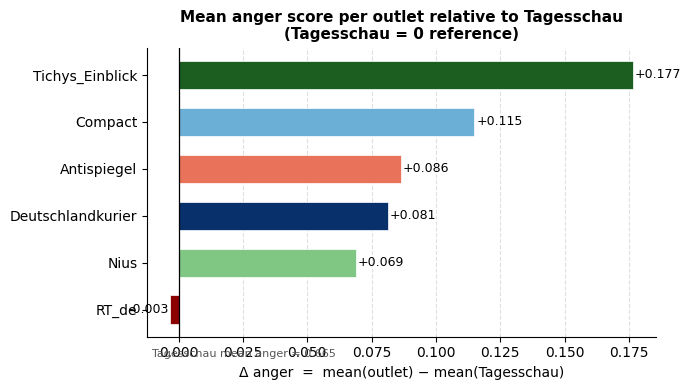

In [ ]:
# ── Δ anger per outlet vs Tagesschau (no topic breakdown) ───────────────────

OUTLET_COLORS = {
    "RT_de":              "#8B0000",   # dark red
    "Antispiegel":        "#E8735A",   # light red
    "Deutschlandkurier":  "#08306B",   # dark blue
    "Compact":            "#6BAED6",   # light blue
    "Tichys_Einblick":    "#1B5E20",   # dark green
    "Nius":               "#81C784",   # light green
}

tg_anger = df.loc[df["source"] == "Tagesschau", anger_col].mean()

outlet_means = (
    df[df["source"].isin(OUTLET_COLORS)]
    .groupby("source")[anger_col]
    .mean()
)
delta = (outlet_means - tg_anger).sort_values(ascending=True)

colors = [OUTLET_COLORS[s] for s in delta.index]

fig, ax = plt.subplots(figsize=(7, max(4, len(delta) * 0.65)))

bars = ax.barh(delta.index, delta.values, color=colors,
               edgecolor="white", linewidth=0.5, height=0.6)

for bar, val in zip(bars, delta.values):
    sign  = "+" if val >= 0 else ""
    x_pos = val + 0.0008 if val >= 0 else val - 0.0008
    ha    = "left" if val >= 0 else "right"
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f"{sign}{val:.3f}", va="center", ha=ha, fontsize=9)

ax.axvline(0, color="black", linewidth=0.9)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlabel("Δ anger  =  mean(outlet) − mean(Tagesschau)", fontsize=10)
ax.set_title(
    "Mean anger score per outlet relative to Tagesschau\n"
    "(Tagesschau = 0 reference)",
    fontsize=11, fontweight="bold",
)
ax.tick_params(axis="y", labelsize=10)
ax.spines[["top", "right"]].set_visible(False)

# Annotate Tagesschau mean for reference
ax.text(0.01, -0.07, f"Tagesschau mean anger = {tg_anger:.3f}",
        transform=ax.transAxes, fontsize=8, color="#555555")

plt.tight_layout()
plt.show()


## fear

###Cluster level

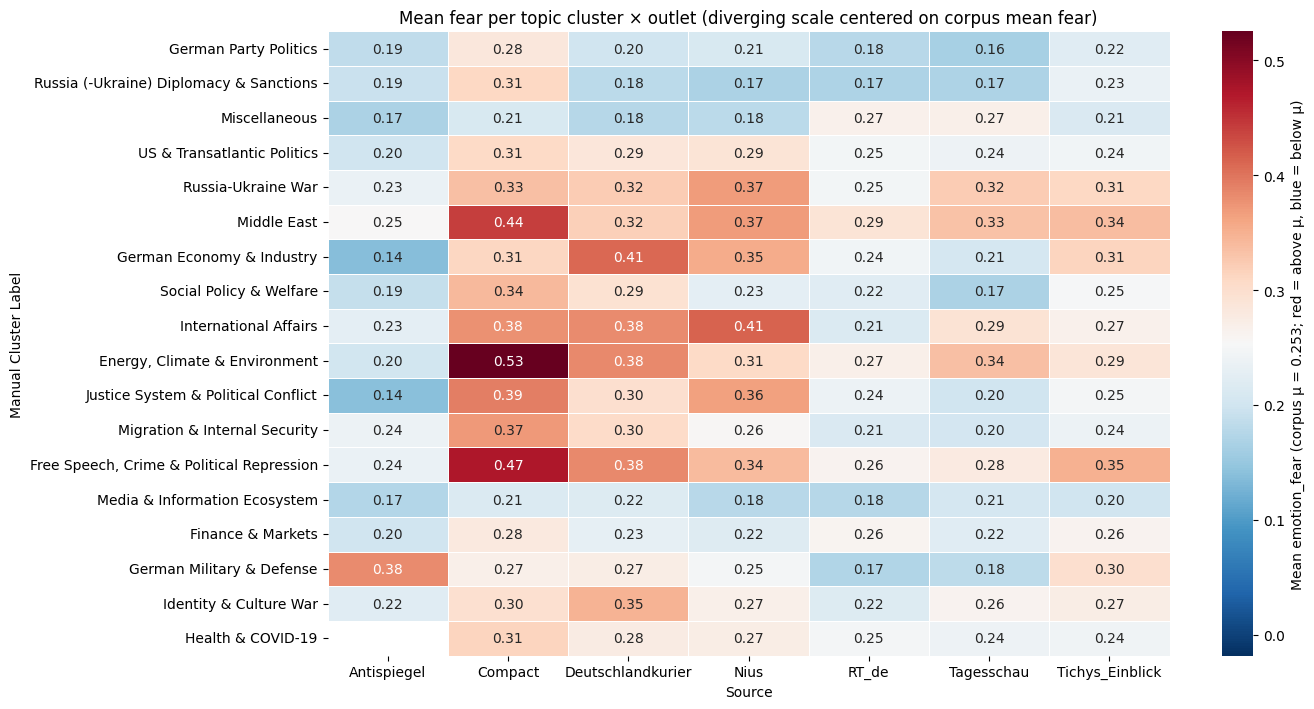

In [ ]:
# Per-topic-cluster × outlet mean anger; colors vs corpus-wide mean anger

if "Manual Cluster Label" not in df.columns or "source" not in df.columns:
    raise ValueError("df must contain 'Manual Cluster Label' and 'source'.")
if not any("fear" in c.lower() for c in df.columns):
    raise ValueError("df must contain an anger score column.")

fear_col = next(c for c in df.columns if "fear" in c.lower())

# Reference: mean fear over the full corpus (same column)
overall_fear_mean = float(df.groupby("source")[fear_col].mean().mean())

major_topics = df["Manual Cluster Label"].value_counts()
major_topics = major_topics[major_topics > 20].index
df_major = df[df["Manual Cluster Label"].isin(major_topics)].copy()

pivot = (
    df_major.groupby(["Manual Cluster Label", "source"])[fear_col]
    .mean()
    .unstack("source")
)

vals = pivot.to_numpy(dtype=float)
lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
spread = max(hi - overall_fear_mean, overall_fear_mean - lo)
if spread == 0:
    spread = 1e-6
vmin = overall_fear_mean - spread
vmax = overall_fear_mean + spread

pivot = pivot.reindex(index=[x for x in major_topics if x in pivot.index])

plt.figure(figsize=(14, max(6, 0.4 * len(pivot))))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=overall_fear_mean,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    cbar_kws={
        "label": f"Mean {fear_col} (corpus μ = {overall_fear_mean:.3f}; red = above μ, blue = below μ)",
    },
)
plt.ylabel("Manual Cluster Label")
plt.xlabel("Source")
plt.title("Mean fear per topic cluster × outlet (diverging scale centered on corpus mean fear)")
plt.tight_layout()
plt.show()



### Topic level

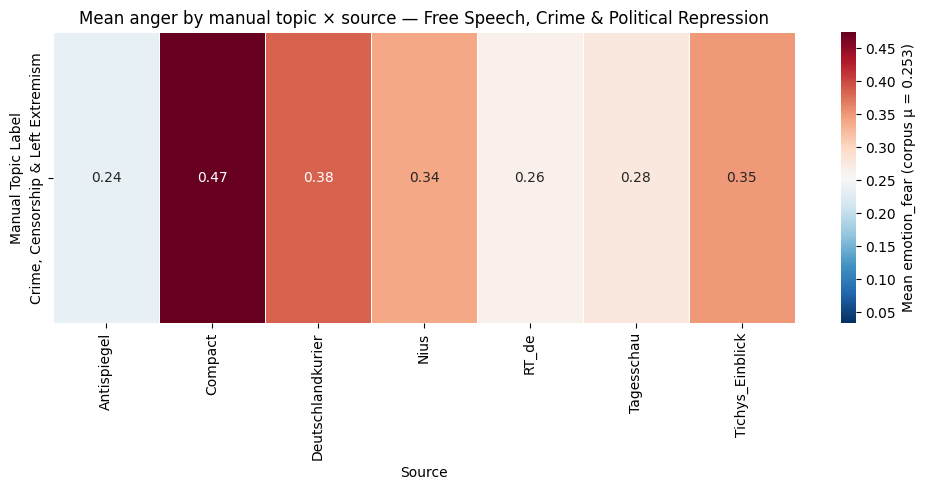

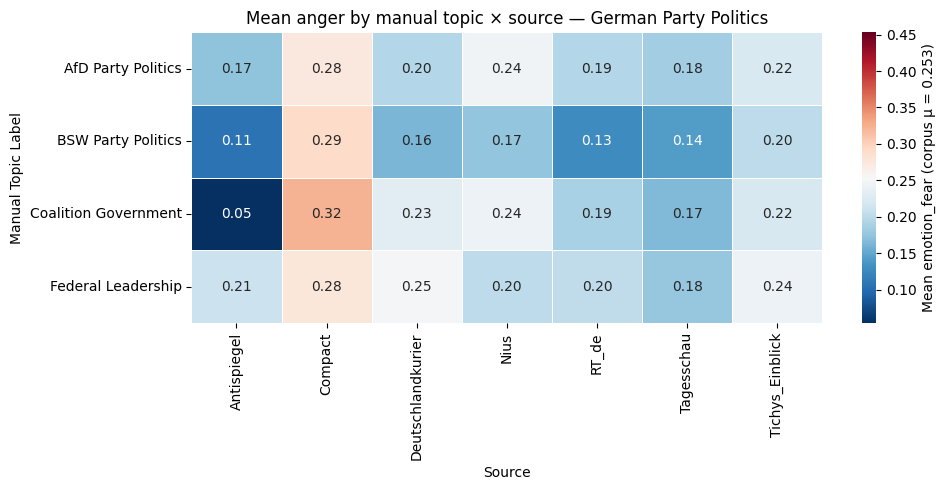

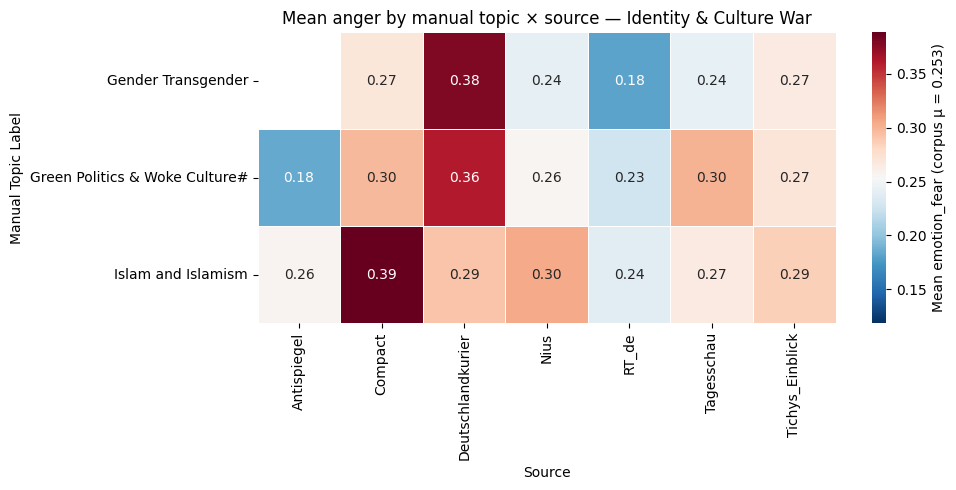

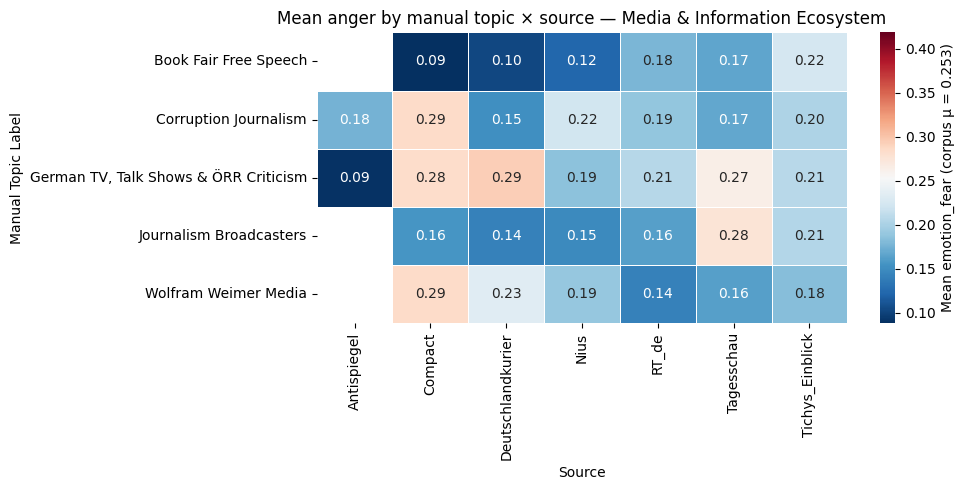

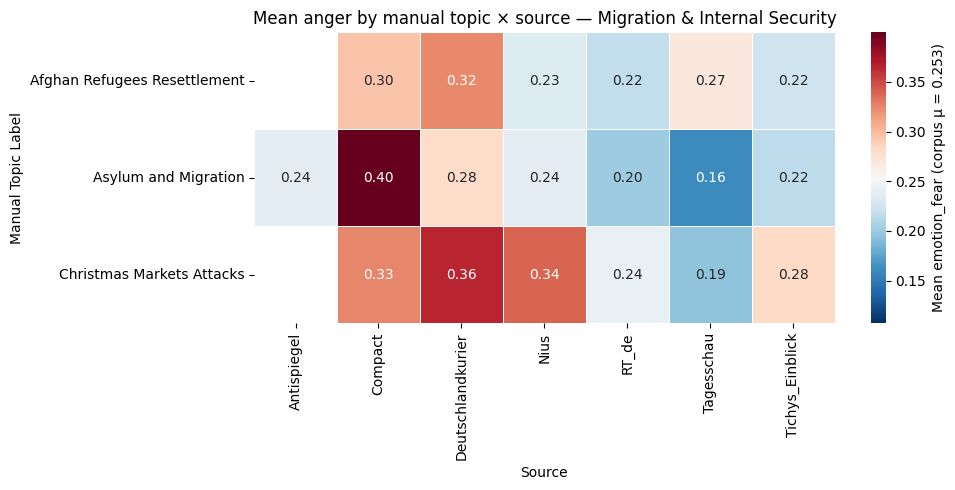

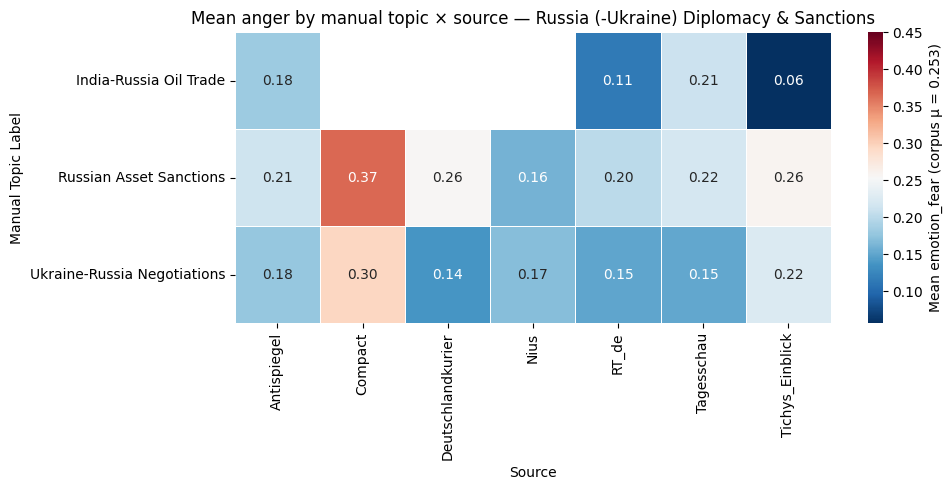

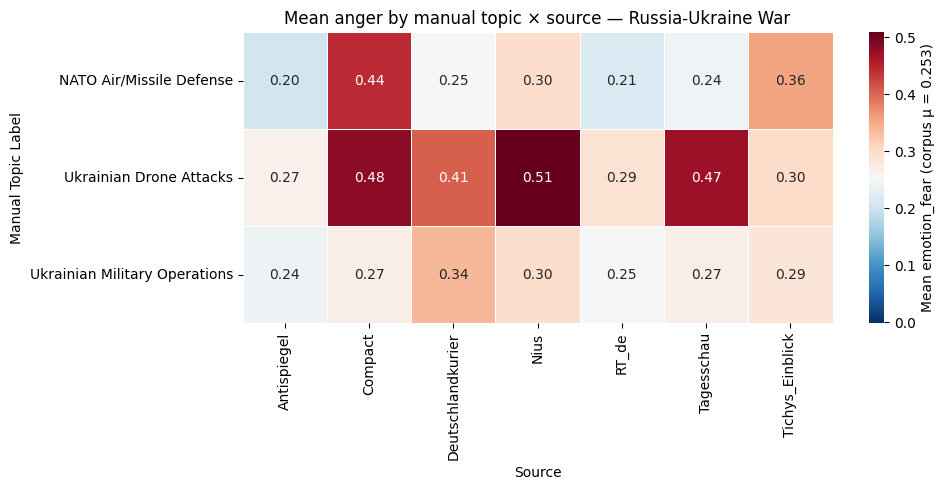

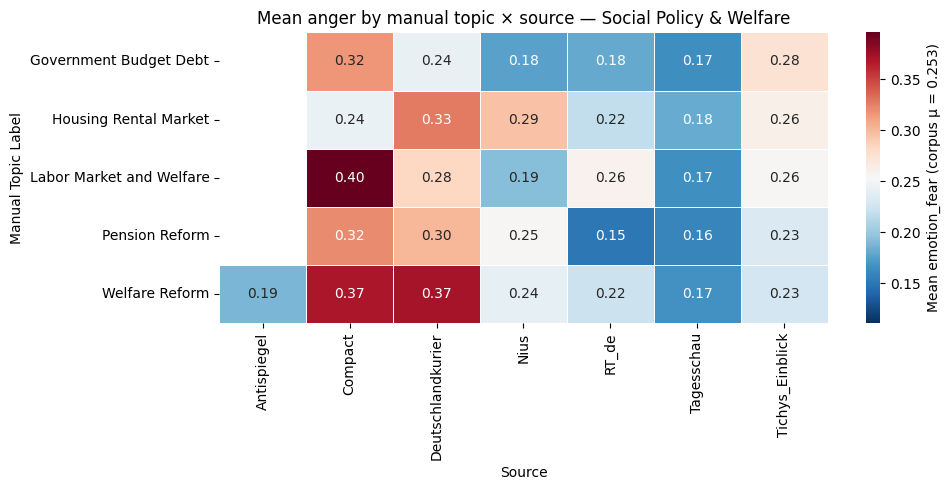

In [ ]:
# One heatmap per selected manual cluster: mean anger by Manual Topic Label × source

fear_col = next(c for c in df.columns if "fear" in c.lower())

available = set(df["Manual Cluster Label"].dropna().astype(str).unique())

for raw in CLUSTER_LABELS:
    resolved = _resolve_manual_cluster(raw, available)
    if resolved is None:
        print(f"Skip (unknown label): {raw!r}")
        continue

    sub = df.loc[df["Manual Cluster Label"] == resolved].copy()
    if sub.empty:
        print(f"Skip (no rows): {resolved!r}")
        continue

    # Topic-level: rows = manual topic, columns = outlet
    pivot = (
        sub.groupby(["Manual Topic Label", "source"])[fear_col]
        .mean()
        .unstack("source")
    )

    # Optional: drop manual topics with very few articles in this cluster
    min_n = 5
    topic_n = sub.groupby("Manual Topic Label", dropna=False).size()
    keep = topic_n[topic_n >= min_n].index
    pivot = pivot.reindex(index=pivot.index.intersection(keep)).sort_index()

    if pivot.empty:
        print(f"Skip (no topics with n≥{min_n}): {resolved!r}")
        continue

    vals = pivot.to_numpy(dtype=float)
    lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
    spread = max(hi - overall_fear_mean, overall_fear_mean - lo)
    if spread == 0:
        spread = 1e-6
    vmin, vmax = overall_fear_mean - spread, overall_fear_mean + spread

    n_r, n_c = pivot.shape
    plt.figure(figsize=(max(10, 0.55 * n_c), max(5, 0.38 * n_r)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=overall_fear_mean,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        cbar_kws={"label": f"Mean {fear_col} (corpus μ = {overall_fear_mean:.3f})"},
    )
    plt.title(f"Mean anger by manual topic × source — {resolved}")
    plt.xlabel("Source")
    plt.ylabel("Manual Topic Label")
    plt.tight_layout()
    plt.show()



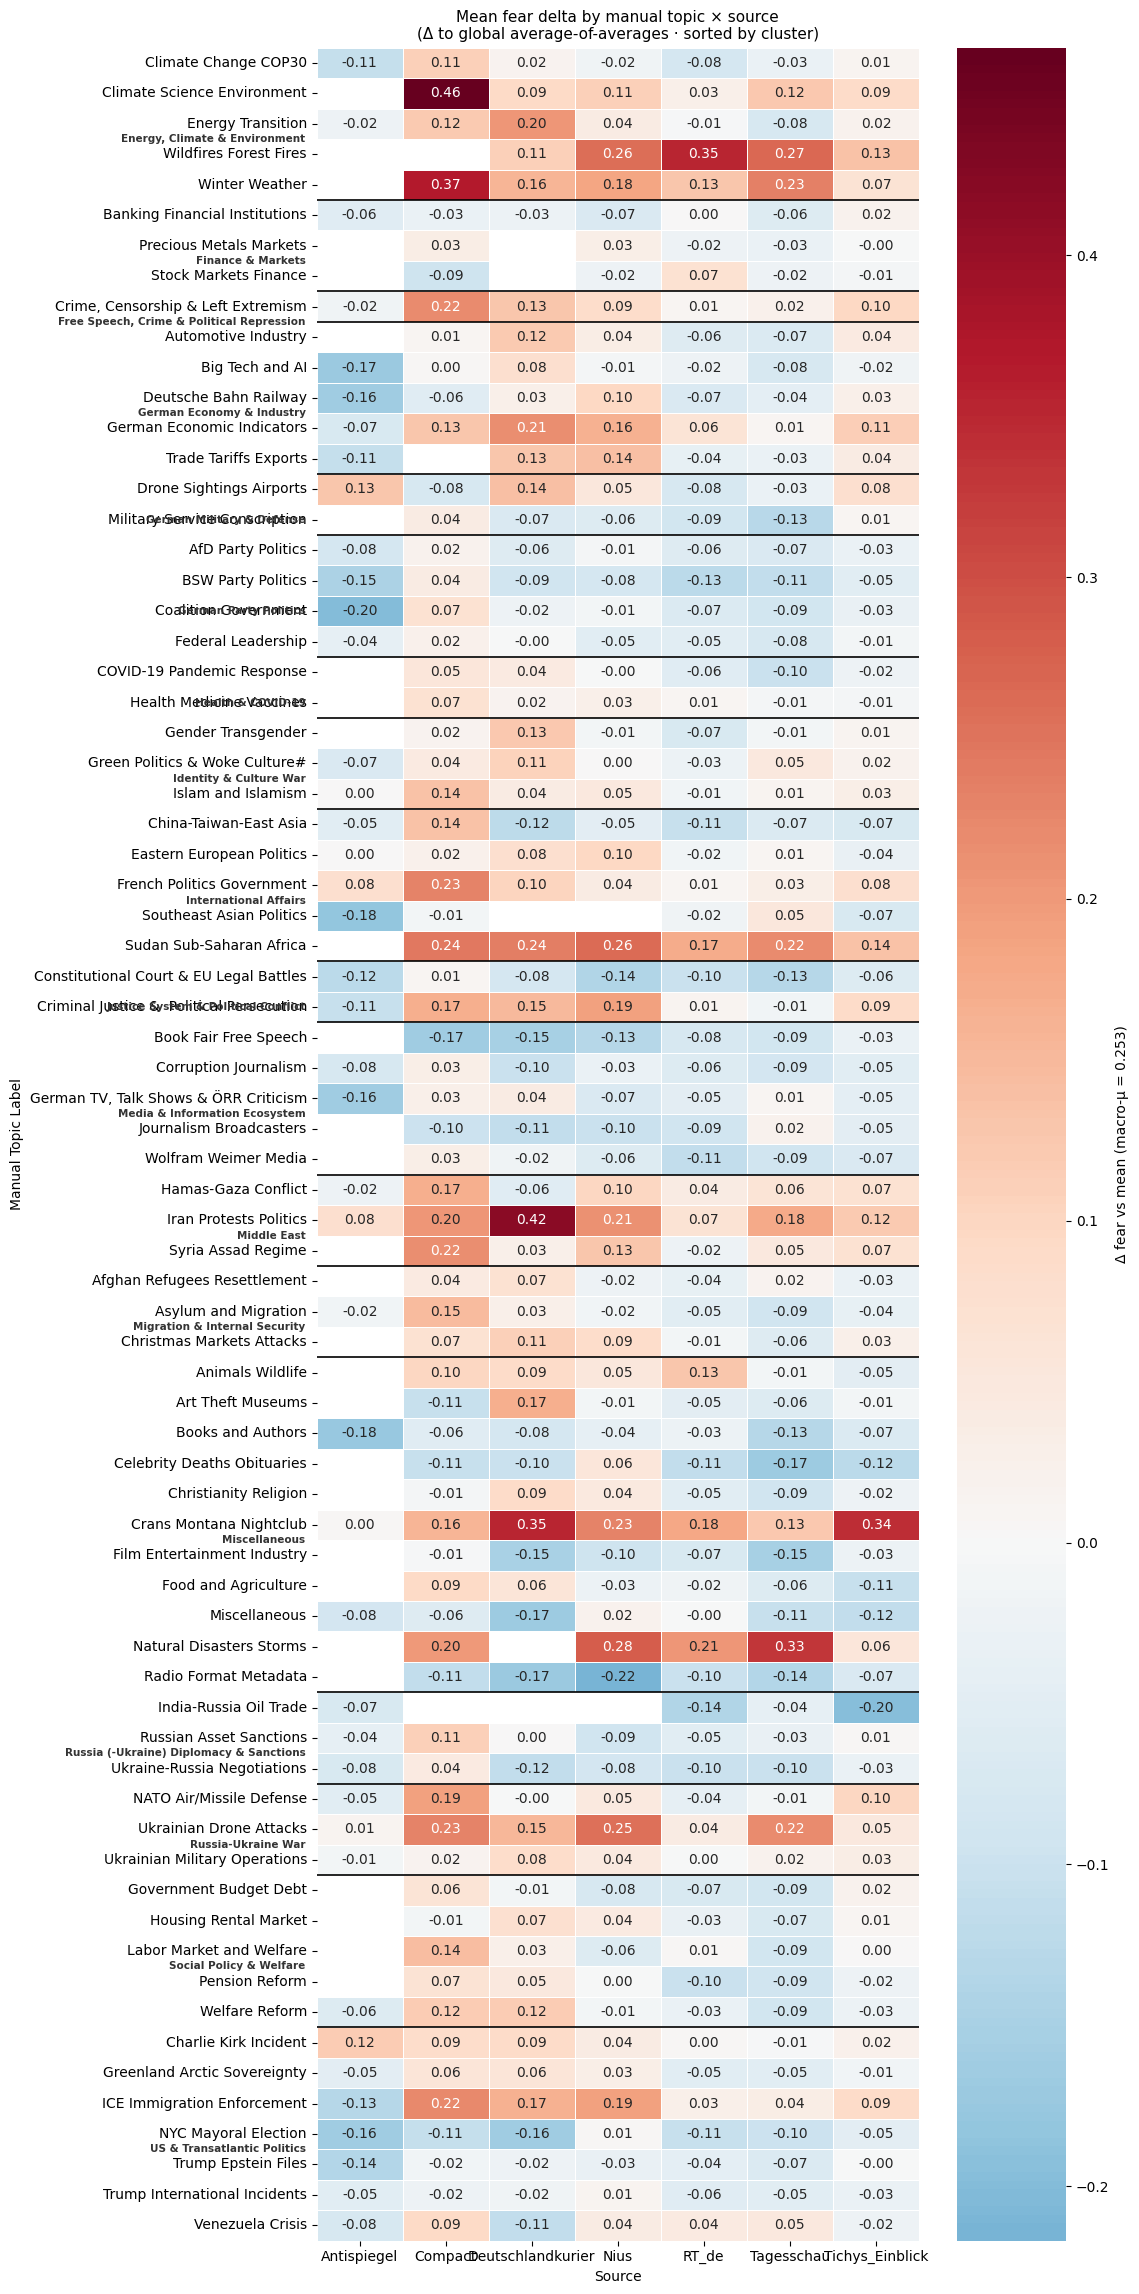

In [ ]:
def _heatmap_clustered(topic_pivot, overall_mean, emotion_name, df):
    """Draw a long heatmap sorted by cluster, with cluster labels on the left."""
    import numpy as np

    # ── min-n filter ──────────────────────────────────────────────────────
    min_n = 5
    topic_counts = df.groupby("Manual Topic Label", dropna=False).size()
    keep_topics  = topic_counts[topic_counts >= min_n].index
    topic_pivot  = topic_pivot.reindex(index=topic_pivot.index.intersection(keep_topics))

    # ── cluster sort order ────────────────────────────────────────────────
    cluster_map = (
        df[["Manual Topic Label", "Manual Cluster Label"]]
        .dropna()
        .drop_duplicates()
        .set_index("Manual Topic Label")["Manual Cluster Label"]
    )
    valid = topic_pivot.index.intersection(cluster_map.index)
    topic_pivot = topic_pivot.loc[valid]
    sort_df = (
        pd.DataFrame({"topic": valid, "cluster": valid.map(cluster_map)})
        .sort_values(["cluster", "topic"])
    )
    topic_pivot = topic_pivot.loc[sort_df["topic"]]
    delta = topic_pivot - overall_mean

    # ── cluster spans for annotations ─────────────────────────────────────
    cl_series = sort_df["cluster"].values
    spans, boundaries = [], []
    prev, start = cl_series[0], 0
    for i, cl in enumerate(cl_series[1:], 1):
        if cl != prev:
            spans.append((prev, start, i))
            boundaries.append(i)
            prev, start = cl, i
    spans.append((prev, start, len(cl_series)))

    # ── figure ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(
        figsize=(max(12, 0.55 * delta.shape[1]),
                 max(7,  0.32 * delta.shape[0]))
    )
    sns.heatmap(
        delta, ax=ax,
        annot=True, fmt=".2f",
        cmap="RdBu_r", center=0,
        linewidths=0.5,
        cbar_kws={"label": f"Δ {emotion_name} vs mean (macro-μ = {overall_mean:.3f})"},
    )

    # ── cluster separator lines ───────────────────────────────────────────
    for b in boundaries:
        ax.axhline(b, color="black", linewidth=1.2)

    # ── cluster labels to the left of the heatmap ─────────────────────────
    for cluster_name, start, end in spans:
        mid = (start + end) / 2 + 0.5
        ax.annotate(
            cluster_name,
            xy=(0, mid),
            xycoords=("axes fraction", "data"),
            xytext=(-8, 0),
            textcoords="offset points",
            ha="right", va="center",
            fontsize=7.5, fontweight="bold",
            annotation_clip=False,
            color="#333333",
        )

    ax.set_title(
        f"Mean {emotion_name} delta by manual topic × source\n"
        f"(Δ to global average-of-averages · sorted by cluster)",
        fontsize=11,
    )
    ax.set_xlabel("Source")
    ax.set_ylabel("Manual Topic Label")
    plt.tight_layout()
    plt.subplots_adjust(left=0.35)   # room for cluster labels
    plt.show()

topic_pivot = (
    df.groupby(["Manual Topic Label", "source"])[fear_col]
    .mean()
    .unstack("source")
)
_heatmap_clustered(topic_pivot, overall_fear_mean, "fear", df)
